# WellSight — Model Training Walkthrough (Pit Detector)

This notebook shows **how a detector is trained**, one step per cell: inputs in → trained model out. It uses the **pit** instance-segmentation model (torchvision Mask R-CNN) as the example; the pad model works the same way.

It imports the real production pieces from `notebooks/wellsight/pits/_pit_maskrcnn.py` and `notebooks/wellsight/_instance_common.py`, so what you see here is exactly what the training script does — just unpacked and visualised.

**Two paths.** Training is *not* bit-for-bit reproducible — shuffled batch order, random head initialisation, and cuDNN nondeterminism mean even the real script gives slightly different weights each run, so we can't re-train our way back to the exact `best.pt` on disk. So this notebook has two parts:

* **Path A — how training works** (cells 0–5): the real method, run as a short seeded *smoke* run so you can watch the loss fall. Illustrative; not the shipped model.
* **Path B — the real model, reproduced exactly** (cell 6): load the committed `best.pt` and run the real inference pipeline. Its outputs are **identical to what we made before** — we check them live against the saved `test_metrics.json`.

Everything imports the real production pieces from `notebooks/wellsight/pits/` and `_instance_common.py`, so what you see is exactly what the scripts do — just unpacked and visualised.

## 0. Inputs — feature stack + annotations

Two things go in:
* **The 7-band feature stack** `features_pit_9t_05.tif` — the terrain derivatives from the *derivatives* notebook, stacked into one image. We load the per-band normalisation stats (`mu`, `sd`) so patches can be z-scored.
* **The annotations** — hand-drawn `pit_inside` (floor) and `pit_outside` (wall) polygons, split into train / val / test.

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\colto\Documents\GitHub\lidar_project")
# put the package dirs on the path so the real modules import cleanly
sys.path.insert(0, str(ROOT / "notebooks" / "wellsight"))
sys.path.insert(0, str(ROOT / "notebooks" / "wellsight" / "pits"))

import _instance_common as ic                       # the shared data helpers
from _pit_maskrcnn import (                          # the real training pieces
    PitPatchDataset, build_model, val_loss, collate, DEVICE,
)

print("device:", DEVICE)
print("feature channels:", ic.FEATURE_CHANNELS)

# per-band mean/std for z-scoring the 7 bands
mu, sd = ic.load_feature_stats()
print("mu:", np.round(mu, 3))
print("sd:", np.round(sd, 3))

# annotations with floor + wall classes, joined to the train/val/test split
pit_set = ic.load_pit_set(with_walls=True)
for split in ("train", "val", "test"):
    g = pit_set.for_split(split)
    print(f"  {split:5s}: {len(g):3d} polygons")

device: cuda
feature channels: ('lrm_25', 'lrm_5', 'slope', 'tpi_05', 'openness_pos', 'openness_neg', 'roughness_11')
mu: [-1.0000e-03 -0.0000e+00  1.0350e+01 -0.0000e+00  8.6820e+01  8.6986e+01
  2.7800e-01]
sd: [0.183 0.034 7.544 0.134 2.749 2.616 0.213]
  train: 148 polygons
  val  :  32 polygons
  test :  40 polygons


## 1. Peek at one labelled example

Load the full feature stack into RAM once (≈1.3 GB, ~20 s), then cut a patch centred on one training pit and show three of its feature bands next to the **floor** (red) and **wall** (cyan) masks the human drew. This is the kind of (input, answer) pair the model learns from.

feature stack: (7, 9000, 9000)


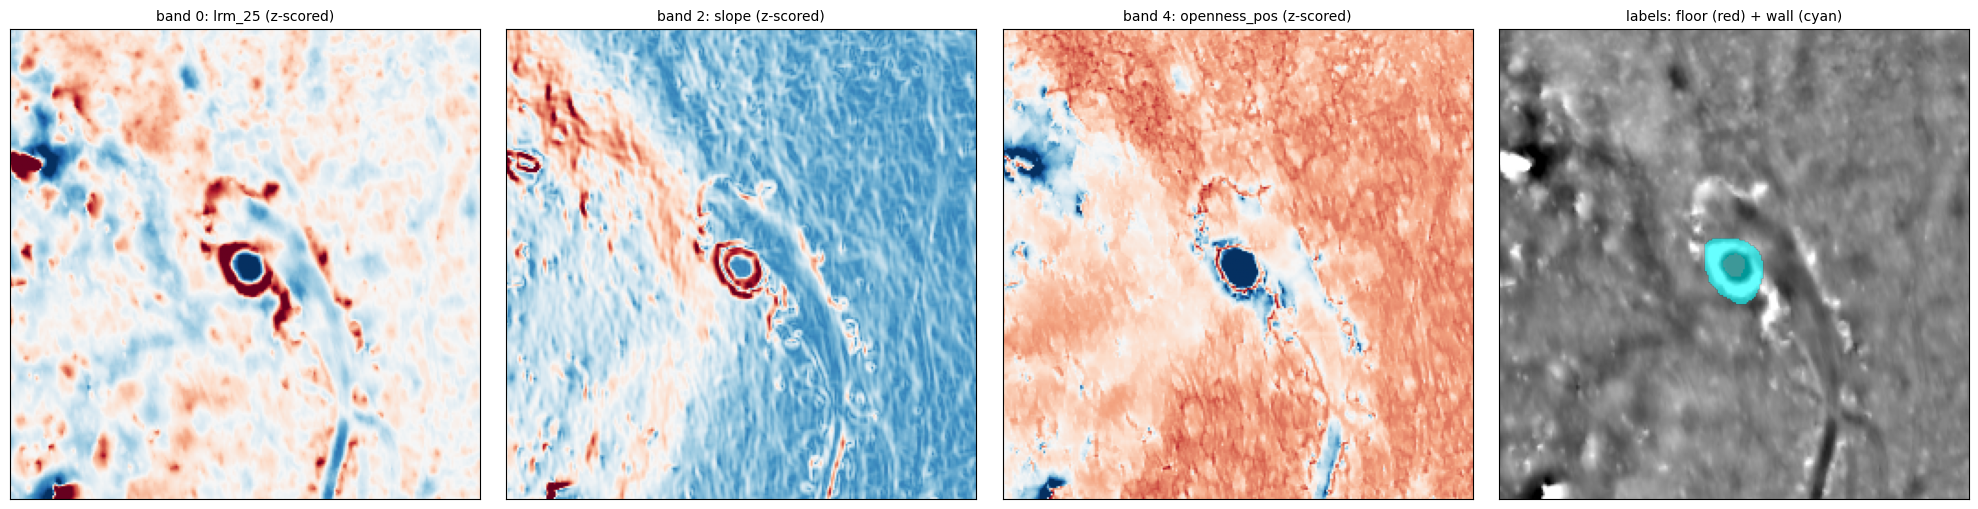

In [2]:
from rasterio.features import rasterize
from shapely.geometry import box as shp_box
import rasterio

# load + z-score the whole stack once; cached in RAM and reused everywhere below
feat_arr = ic.load_feature_array(mu, sd)          # (7, H, W) float32
parent_tf = ic.feature_parent_transform()
print("feature stack:", feat_arr.shape)

# pick one training pit (its floor polygon) and centre a patch on it
train_floor = pit_set.for_split("train")
train_floor = train_floor[train_floor.cls == "floor"] if "cls" in train_floor.columns else train_floor
g0 = train_floor.geometry.iloc[0]
cx, cy = g0.centroid.x, g0.centroid.y
PATCH = 256
win = ic.patch_window_around(float(cx), float(cy), parent_tf, PATCH)
patch = ic.slice_feat_patch(feat_arr, win)         # (7, 256, 256) z-scored

# rasterize the floor + wall polygons that fall in this window, for display
tf = rasterio.windows.transform(win, parent_tf)
minx, miny, maxx, maxy = rasterio.windows.bounds(win, parent_tf)
pbox = shp_box(minx, miny, maxx, maxy)
polys = ic.polygons_intersecting(pit_set.gdf, win, parent_tf)
floor_m = np.zeros((PATCH, PATCH), np.uint8)
wall_m  = np.zeros((PATCH, PATCH), np.uint8)
for r in polys.itertuples():
    clip = r.geometry.intersection(pbox)
    if clip.is_empty:
        continue
    m = rasterize([(clip, 1)], out_shape=(PATCH, PATCH), transform=tf, fill=0, dtype="uint8")
    if getattr(r, "cls", "floor") == "wall":
        wall_m |= m
    else:
        floor_m |= m

# show three feature bands + the masks overlaid on band 0
names = ic.FEATURE_CHANNELS
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, b in zip(axes[:3], (0, 2, 4)):
    ax.imshow(patch[b], cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_title(f"band {b}: {names[b]} (z-scored)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
ax = axes[3]
ax.imshow(patch[0], cmap="gray", vmin=-2, vmax=2)
ax.imshow(np.ma.masked_where(floor_m == 0, floor_m), cmap="autumn", alpha=0.6)
ax.imshow(np.ma.masked_where(wall_m == 0, wall_m), cmap="cool", alpha=0.6)
ax.set_title("labels: floor (red) + wall (cyan)", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Build the patch dataset

`PitPatchDataset` turns the polygons into training samples. For each pit it cuts a 256×256 patch; for the **train** split it makes several per pit, each nudged by a random offset (*jitter*) so the model can't memorise exact positions. Each sample is a `(feature_patch, target)` pair, where the target is the torchvision dict: boxes + per-instance masks + class labels (1=floor, 2=wall).

We use a small `patches_per_inst` here to keep the smoke run quick.

train patches: 148   val patches: 16
feature patch tensor: (7, 256, 256) torch.float32
  boxes : (2, 4) (x0,y0,x1,y1 per instance)
  labels: [2, 1]  (1=floor, 2=wall)
  masks : (2, 256, 256) (one binary mask per instance)


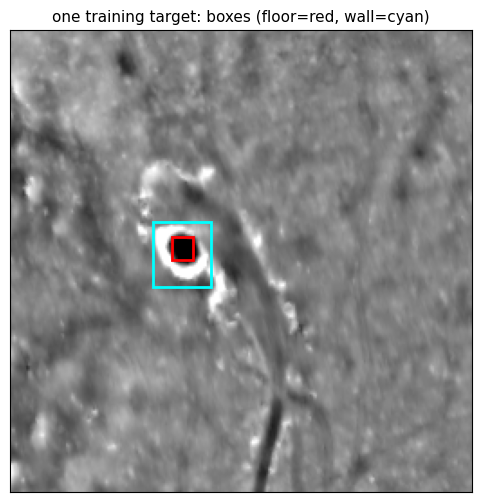

In [3]:
SMOKE_PATCHES_PER_INST = 2     # production default is 4

train_ds = PitPatchDataset(pit_set, "train", mu, sd, seed=42,
                           patches_per_inst=SMOKE_PATCHES_PER_INST)
val_ds   = PitPatchDataset(pit_set, "val",   mu, sd, seed=43,
                           patches_per_inst=1)
print(f"train patches: {len(train_ds)}   val patches: {len(val_ds)}")

# pull one sample and inspect the target the model will be trained against
feat_t, target = train_ds[0]
print("feature patch tensor:", tuple(feat_t.shape), feat_t.dtype)
print("  boxes :", tuple(target["boxes"].shape), "(x0,y0,x1,y1 per instance)")
print("  labels:", target["labels"].tolist(), " (1=floor, 2=wall)")
print("  masks :", tuple(target["masks"].shape), "(one binary mask per instance)")

# draw the boxes over band 0 of the patch
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(feat_t[0].numpy(), cmap="gray", vmin=-2, vmax=2)
for (x0, y0, x1, y1), lab in zip(target["boxes"].tolist(), target["labels"].tolist()):
    color = "red" if lab == 1 else "cyan"
    ax.add_patch(mpatches.Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                                    edgecolor=color, linewidth=2))
ax.set_title("one training target: boxes (floor=red, wall=cyan)", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 3. Build the model

`build_model` starts from a **COCO-pretrained** Mask R-CNN (`maskrcnn_resnet50_fpn_v2`, ~45.9 M params) and adapts it two ways:
* **First-conv widening** — the pretrained stem expects 3 channels (RGB); we replace it with a 7-channel conv, copying the RGB weights into the first 3 slots and warm-starting the extra 4 from their mean. This keeps all the pretrained shape/edge knowledge while accepting our 7-band stack.
* **New heads** — the classification/box and mask heads are reinitialised for **3 classes** (background / floor / wall).

In [4]:
n_ch = len(ic.FEATURE_CHANNELS)
model = build_model(num_classes=3, in_channels=n_ch).to(DEVICE)

conv1 = model.backbone.body.conv1
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"params: {n_params:.1f} M")
print(f"stem conv1 now accepts {conv1.in_channels} input channels "
      f"(was 3 for RGB) -> out {conv1.out_channels}")
print("box predictor classes:", model.roi_heads.box_predictor.cls_score.out_features,
      "(bg / floor / wall)")

params: 45.9 M
stem conv1 now accepts 7 input channels (was 3 for RGB) -> out 64
box predictor classes: 3 (bg / floor / wall)


## 4. Train (smoke run)

The training loop is the heart of it: for each batch of patches the model **predicts**, the loss says **how wrong** it was (Mask R-CNN sums five losses: region-proposal objectness + box, then classifier + box-refine + mask), we **back-propagate**, clip the gradients, and the optimizer **nudges** the weights. After each epoch we measure validation loss the same way. (The real script runs ~30 epochs with a cosine learning-rate schedule and saves the best-val checkpoint to `best.pt`.)

  epoch 0:  train_loss=0.729   val_loss=0.569


  epoch 1:  train_loss=0.509   val_loss=0.614


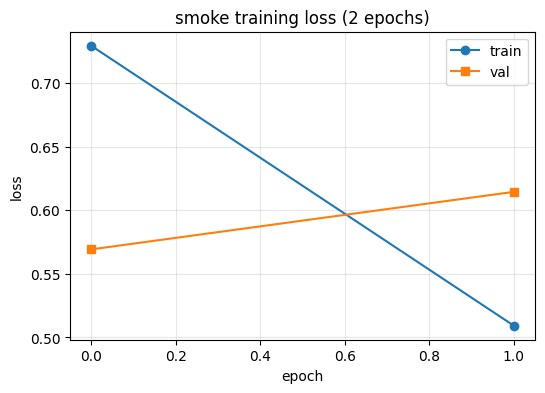

In [5]:
import random
from torch.utils.data import DataLoader

# Seed everything so THIS smoke run is reproducible from run to run on this
# machine. (This still won't reproduce the committed best.pt, which was trained
# without pinned seeds — that's what Path B in cell 6 is for.)
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
g = torch.Generator(); g.manual_seed(SEED)

EPOCHS = 2          # smoke; production uses ~30
BATCH  = 2
LR     = 5e-4

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, collate_fn=collate, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=0, collate_fn=collate)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                              lr=LR, weight_decay=1e-4)

history = []
for epoch in range(EPOCHS):
    model.train()
    running, n = 0.0, 0
    for imgs, targets in train_loader:
        imgs = [im.to(DEVICE) for im in imgs]
        targets = [{k: (v.to(DEVICE) if torch.is_tensor(v) else v) for k, v in t.items()}
                   for t in targets]
        if all(len(t["boxes"]) == 0 for t in targets):   # skip empty patches
            continue
        loss_dict = model(imgs, targets)       # forward -> dict of 5 losses
        loss = sum(loss_dict.values())         # total loss
        optimizer.zero_grad()
        loss.backward()                        # back-propagate
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()                       # update weights
        running += float(loss); n += 1
    tr = running / max(n, 1)
    va = val_loss(model, val_loader)           # same loss, no weight update
    history.append((tr, va))
    print(f"  epoch {epoch}:  train_loss={tr:.3f}   val_loss={va:.3f}")

# plot the (very short) loss curve
h = np.array(history)
plt.figure(figsize=(6, 4))
plt.plot(h[:, 0], "o-", label="train")
plt.plot(h[:, 1], "s-", label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("smoke training loss (2 epochs)"); plt.grid(alpha=0.3); plt.show()

## 5. Run the *smoke* model on a held-out patch (Path A result)

Put the smoke model in eval mode and run it on a patch centred on a **test** pit it never saw. It returns boxes, masks, and confidence scores; we keep detections above score 0.3 and draw their masks. **With only 2 epochs the masks are rough** — this just shows the input → prediction path. For the real, accurate result, see cell 6 below.

detections above score 0.3: 3  (raw 13)


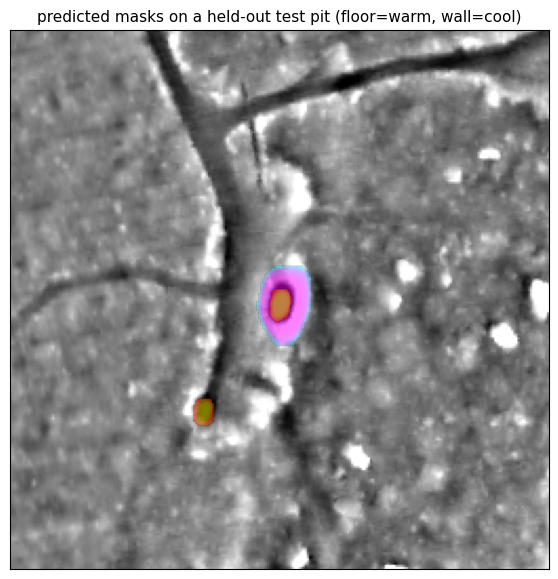

In [6]:
model.eval()

# centre a patch on a test-split pit
test_floor = pit_set.for_split("test")
test_floor = test_floor[test_floor.cls == "floor"] if "cls" in test_floor.columns else test_floor
gt = test_floor.geometry.iloc[0]
win = ic.patch_window_around(float(gt.centroid.x), float(gt.centroid.y), parent_tf, PATCH)
patch = ic.slice_feat_patch(feat_arr, win)
img_t = torch.from_numpy(patch).to(DEVICE)

with torch.no_grad():
    out = model([img_t])[0]
scores = out["scores"].cpu().numpy()
masks  = out["masks"].cpu().numpy()[:, 0]
labels = out["labels"].cpu().numpy()
keep = scores >= 0.3
print(f"detections above score 0.3: {keep.sum()}  (raw {len(scores)})")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(patch[0], cmap="gray", vmin=-2, vmax=2)
for m, lab, s in zip(masks[keep], labels[keep], scores[keep]):
    cmap = "autumn" if lab == 1 else "cool"
    ax.imshow(np.ma.masked_where(m < 0.5, m), cmap=cmap, alpha=0.5)
ax.set_title("predicted masks on a held-out test pit (floor=warm, wall=cool)", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 6. Path B — reproduce the production model *exactly*

This is the part that is **identical to what we made before**. Instead of training (which can't land on the exact saved weights), we **load the committed `best.pt`** and run the genuine full-tile inference pipeline from `_pit_maskrcnn_infer.py`:

1. slide a 256×256 window over the whole feature tile,
2. keep detections with score ≥ 0.3,
3. de-duplicate with per-class non-maximum suppression,
4. score per-instance recall/IoU against the held-out test pits.

Eval-mode inference is deterministic, so the numbers below should match the saved `test_metrics.json` **to the last digit**. We assert it at the end.

*(This is the heavy cell — it runs ~2,200 windows over the full tile, a few minutes on the GPU. The per-window progress is printed every 50 windows.)*

In [7]:
import json
import geopandas as gpd
from _pit_maskrcnn_infer import run_inference, global_nms, OVERLAP, SCORE_THRESH, NMS_IOU

# free the smoke model from the GPU first — this is an 8 GB card and we're about
# to load a second 45.9 M-param model for full-tile inference.
for _name in ("model", "optimizer"):
    if _name in dir():
        del globals()[_name]
torch.cuda.empty_cache()

ITER_DIR = ROOT / "data/derivatives/tiles/9t/iterations/pit_07_maskrcnn"

# --- load the REAL trained weights (not the smoke model) --------------------
ck = torch.load(ITER_DIR / "best.pt", map_location=DEVICE, weights_only=False)
real_model = build_model(num_classes=ck["num_classes"],
                         in_channels=ck["in_channels"]).to(DEVICE)
real_model.load_state_dict(ck["state_dict"])
mu_r = np.asarray(ck["mu"], np.float32); sd_r = np.asarray(ck["sd"], np.float32)
print(f"loaded best.pt  (epoch {ck['epoch']}, val_loss {ck['val_loss']:.3f})")

# --- the genuine full-tile inference pipeline -------------------------------
dets = run_inference(real_model, mu_r, sd_r, PATCH, OVERLAP)   # ~2,200 windows
for x in dets:
    x["cls"] = {1: "floor", 2: "wall"}.get(x["cls_id"], "floor")
dets = global_nms(dets, NMS_IOU)
n_floor = sum(x["cls"] == "floor" for x in dets)
n_wall  = sum(x["cls"] == "wall"  for x in dets)

# --- polygonise + score against the test split (writes to the demo folder) --
ref = ic.reference_profile()
demo_dir = ROOT / "data/derivatives/experiments/notebook_demo"
demo_dir.mkdir(parents=True, exist_ok=True)
repro_gpkg = demo_dir / "_repro_instances.gpkg"
repro_gpkg.unlink(missing_ok=True)
ic.detections_to_gpkg(dets, ref, repro_gpkg, layer="pits", score_thresh=SCORE_THRESH)
pred = gpd.read_file(repro_gpkg, layer="pits")
pred_floor = pred[pred.cls == "floor"]
_, metrics = ic.per_instance_metrics(pred_floor, ic.load_pit_set(with_walls=False),
                                     split="test")
metrics["n_detections_after_nms"] = len(dets)
metrics["n_floor"] = n_floor; metrics["n_wall"] = n_wall

# --- compare to what we saved before ----------------------------------------
committed = json.loads((ITER_DIR / "test_metrics.json").read_text())
keys = ["recall_at_iou_0.1", "recall_at_iou_0.3", "recall_at_iou_0.5",
        "mean_best_iou", "n_detections_after_nms", "n_floor", "n_wall"]
print(f"\n{'metric':24s} {'reproduced':>20s} {'committed':>20s}  match")
all_match = True
for k in keys:
    a, b = metrics.get(k), committed.get(k)
    ok = (a == b)
    all_match &= ok
    print(f"  {k:22s} {str(a):>20s} {str(b):>20s}  {'OK' if ok else 'DIFF'}")
assert all_match, "Reproduced metrics do not match the committed run!"
print("\nIDENTICAL to the committed production run.")

loaded best.pt  (epoch 1, val_loss 0.488)
Sliding inference: 2209 windows (9000x9000, patch=256, overlap=64)
  window 1/2209


  window 51/2209


  window 101/2209


  window 151/2209


  window 201/2209


...

  window 2051/2209


  window 2101/2209


  window 2151/2209


  window 2201/2209


  wrote _repro_instances.gpkg (2037 instances)

metric                             reproduced            committed  match
  recall_at_iou_0.1                       1.0                  1.0  OK
  recall_at_iou_0.3                       1.0                  1.0  OK
  recall_at_iou_0.5                      0.95                 0.95  OK
  mean_best_iou            0.6644931751455998   0.6644931751455998  OK
  n_detections_after_nms                 2027                 2027  OK
  n_floor                                 947                  947  OK
  n_wall                                 1080                 1080  OK

IDENTICAL to the committed production run.


## Recap — how this maps to the real pipeline

| Notebook step | Production code |
|---|---|
| Load stats + annotations | `_instance_common.load_feature_stats` / `load_pit_set` |
| Patch dataset + jitter | `_pit_maskrcnn.PitPatchDataset` |
| Build model (conv1 widening) | `_pit_maskrcnn.build_model` |
| Train loop + val loss | `_pit_maskrcnn.train_one_epoch` / `val_loss` → saves `best.pt` |
| Per-patch inference (Path A) | scaled up to a sliding window in `_pit_maskrcnn_infer.py` |
| **Reproduce real model (Path B)** | `_pit_maskrcnn_infer.run_inference` + `global_nms` on `best.pt` → matches `test_metrics.json` |

**On reproducibility:** the *derivatives* are deterministic, so that notebook reproduces our rasters bit-for-bit. *Training* is stochastic, so Path A is only reproducible run-to-run (seeded); to get outputs identical to what we shipped, Path B loads the committed `best.pt` and re-runs the deterministic inference — which it verifies against the saved metrics.

**To train for real** (saves `best.pt`, logs per-epoch metrics):
```
python notebooks/wellsight/pits/_pit_maskrcnn.py --epochs 30 --batch 4
```
**Then run full-tile inference + scoring:**
```
python notebooks/wellsight/pits/_pit_maskrcnn_infer.py
```
The pad detector mirrors this exactly via `plats/_pad_maskrcnn.py` (patch 384, single foreground class).